In [1]:
import pandas as pd

url = "https://files.consumerfinance.gov/ccdb/complaints.csv.zip"

credit_reporting_variants = [
    'Credit reporting',
    'Credit reporting or other personal consumer reports',
    'Credit reporting, credit repair services, or other personal consumer reports'
]

payday_variants = [
    'Payday loan',
    'Payday loan, title loan, or personal loan',
    'Payday loan, title loan, personal loan, or advance loan'
]

bank_variants = [
    'Bank account or service',
    'Checking or savings account'
]

credit_card_variants = [
    'Credit card',
    'Credit card or prepaid card',
    'Prepaid card'
]

money_transfer_variants = [
    'Money transfers',
    'Virtual currency',
    'Money transfer, virtual currency, or money service'
]

company_response_variants = [
    'Closed',
    'Closed with explanation'
]

referral_variants = [
    'Referral',
    'Web Referral'
]

manual_variants = [
    'Email',
    'Fax',
    'Postal mail'
]

needed_cols = [
    'Date received',
    'Date sent to company',
    'Product',
    'Submitted via',
    'Company response to consumer',
    'Timely response?'
]

start_date = pd.to_datetime('2017-01-20')

print("Processing in chunks to save RAM...")

chunks = []
for chunk in pd.read_csv(url,
                         compression='zip',
                         usecols=needed_cols,
                         chunksize=100000,
                         low_memory=False):
    chunk['Product'] = chunk['Product'].replace(credit_reporting_variants, 'Credit Reporting')
    chunk['Product'] = chunk['Product'].replace(payday_variants, 'Payday Loan')
    chunk['Product'] = chunk['Product'].replace(bank_variants, 'Bank Account or Service')
    chunk['Product'] = chunk['Product'].replace(credit_card_variants, 'Credit Card or Prepaid Card')
    chunk['Product'] = chunk['Product'].replace(money_transfer_variants, 'Money Transfer, Virtual Currency, or Money Service')
    chunk['Company response to consumer'] = chunk['Company response to consumer'].replace(company_response_variants, 'Closed with Explanation')
    chunk['Submitted via'] = chunk['Submitted via'].replace(manual_variants, 'Email, Fax, or Postal Mail')
    chunk['Submitted via'] = chunk['Submitted via'].replace(referral_variants, 'Referral')
    chunk['Date received'] = pd.to_datetime(chunk['Date received'])
    filtered_chunk = chunk[chunk['Date received'] >= start_date]

    chunks.append(filtered_chunk)

df = pd.concat(chunks, ignore_index=True)

print(f"Success! Dataframe loaded with {len(df):,} rows.")
print(f"Date range: {df['Date received'].min().date()} to {df['Date received'].max().date()}")

df.head()

Processing in chunks to save RAM...
Success! Dataframe loaded with 13,443,074 rows.
Date range: 2017-01-20 to 2026-03-25


,Date received,Product,Submitted via,Date sent to company,Company response to consumer,Timely response?
0,2020-07-06,Credit Reporting,Web,2020-07-06,Closed with Explanation,Yes
1,2019-12-26,Credit Card or Prepaid Card,Web,2019-12-26,Closed with Explanation,Yes
2,2020-05-08,Credit Reporting,Web,2020-05-08,Closed with Explanation,Yes
3,2024-01-05,Credit Reporting,Web,2024-01-05,Closed with non-monetary relief,Yes
4,2024-01-21,Credit Reporting,Web,2024-01-21,Closed with Explanation,Yes


In [2]:
df.shape

(13443074, 6)

In [3]:
new_names = {'Date received': 'date_received', 'Product': 'product', 'Submitted via':'submitted_via', 'Date sent to company':'date_sent_to_company', 'Company response to consumer':'company_response_to_consumer', 'Timely response?':'timely_response'}
df = df.rename(columns=new_names)
categorical_cols = ['product', 'submitted_via', 'company_response_to_consumer', 'timely_response']
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [4]:
fraction_similar = (((df['date_received'] == df['date_sent_to_company']).sum())/df.shape[0])
print(f"Similarity between the date the CFPB received the complaint and the date the CFPB sent the complaint to the company: {fraction_similar:.2%}")

Similarity between the date the CFPB received the complaint and the date the CFPB sent the complaint to the company: 95.15%


In [5]:
# https://cfpb.github.io/api/ccdb/fields.html
df.drop('date_received', axis = 1, inplace = True)
df['date_sent_to_company'] = pd.to_datetime(df['date_sent_to_company'])
df.head()

,product,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response
0,Credit Reporting,Web,2020-07-06,Closed with Explanation,Yes
1,Credit Card or Prepaid Card,Web,2019-12-26,Closed with Explanation,Yes
2,Credit Reporting,Web,2020-05-08,Closed with Explanation,Yes
3,Credit Reporting,Web,2024-01-05,Closed with non-monetary relief,Yes
4,Credit Reporting,Web,2024-01-21,Closed with Explanation,Yes


In [6]:
df = df[df['company_response_to_consumer'] != 'In progress']
bins = [
    pd.Timestamp('2017-01-20'),
    pd.Timestamp('2021-01-20'),
    pd.Timestamp('2025-01-20'),
    pd.Timestamp('2029-01-20')
]

labels = ['Trump_One', 'Biden', 'Trump_Two']

df['president_date_sent_to_company'] = pd.cut(df['date_sent_to_company'], bins=bins, labels=labels, right=False, ordered=False)
df.head()

,product,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,president_date_sent_to_company
0,Credit Reporting,Web,2020-07-06,Closed with Explanation,Yes,Trump_One
1,Credit Card or Prepaid Card,Web,2019-12-26,Closed with Explanation,Yes,Trump_One
2,Credit Reporting,Web,2020-05-08,Closed with Explanation,Yes,Trump_One
3,Credit Reporting,Web,2024-01-05,Closed with non-monetary relief,Yes,Biden
4,Credit Reporting,Web,2024-01-21,Closed with Explanation,Yes,Biden


In [7]:
df['product'].value_counts()

,count
product,
Credit Reporting,10626406
Debt collection,899437
Credit Card or Prepaid Card,432564
Bank Account or Service,353625
Mortgage,224825
"Money Transfer, Virtual Currency, or Money Service",171586
Student loan,97781
Vehicle loan or lease,90018
Payday Loan,58831


In [8]:
df['submitted_via'].value_counts()

,count
submitted_via,
Web,12581838
Phone,162470
Referral,144569
"Email, Fax, or Postal Mail",77217


In [9]:
df['company_response_to_consumer'].value_counts()

,count
company_response_to_consumer,
Closed with Explanation,7889009
Closed with non-monetary relief,4901505
Closed with monetary relief,153570
Untimely response,21989
In progress,0


In [10]:
# df = df[df['product'] != 'Virtual currency']
df = df[df['product'] != 'Other financial service']
# df = df[df['product'] != 'Money transfers']
# df = df[df['submitted_via'] != 'Email']
# df = df[df['submitted_via'] != 'Web Referral']

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12965960 entries, 0 to 13443073
Data columns (total 6 columns):
 #   Column                          Dtype         
---  ------                          -----         
 0   product                         category      
 1   submitted_via                   category      
 2   date_sent_to_company            datetime64[ns]
 3   company_response_to_consumer    category      
 4   timely_response                 category      
 5   president_date_sent_to_company  category      
dtypes: category(5), datetime64[ns](1)
memory usage: 259.7 MB


In [12]:
df.drop('date_sent_to_company', axis = 1, inplace = True)

In [13]:
df.describe(include='all')

,product,submitted_via,company_response_to_consumer,timely_response,president_date_sent_to_company
count,12965960,12965960,12965939,12965960,12965960
unique,11,4,4,2,3
top,Credit Reporting,Web,Closed with Explanation,Yes,Trump_Two
freq,10626406,12581757,7888901,12892399,6162139


In [14]:
missing_values = df.isnull().sum()

missing_values_percentage = (missing_values / len(df)) * 100

missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_values_percentage})
missing_data.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
company_response_to_consumer,21,0.000162
product,0,0.000000
submitted_via,0,0.000000
timely_response,0,0.000000
president_date_sent_to_company,0,0.000000


In [15]:
df.dropna(inplace=True)
df.head()

,product,submitted_via,company_response_to_consumer,timely_response,president_date_sent_to_company
0,Credit Reporting,Web,Closed with Explanation,Yes,Trump_One
1,Credit Card or Prepaid Card,Web,Closed with Explanation,Yes,Trump_One
2,Credit Reporting,Web,Closed with Explanation,Yes,Trump_One
3,Credit Reporting,Web,Closed with non-monetary relief,Yes,Biden
4,Credit Reporting,Web,Closed with Explanation,Yes,Biden


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack

ohe_cols = ['product', 'submitted_via', 'company_response_to_consumer',
       'timely_response']
encoder = OneHotEncoder(sparse_output=True, drop='first')
X_sparse = encoder.fit_transform(df[ohe_cols])

In [17]:
column_names = encoder.get_feature_names_out(ohe_cols)
column_names

array(['product_Consumer Loan', 'product_Credit Card or Prepaid Card',
       'product_Credit Reporting', 'product_Debt collection',
       'product_Debt or credit management',
       'product_Money Transfer, Virtual Currency, or Money Service',
       'product_Mortgage', 'product_Payday Loan', 'product_Student loan',
       'product_Vehicle loan or lease', 'submitted_via_Phone',
       'submitted_via_Referral', 'submitted_via_Web',
       'company_response_to_consumer_Closed with monetary relief',
       'company_response_to_consumer_Closed with non-monetary relief',
       'company_response_to_consumer_Untimely response',
       'timely_response_Yes'], dtype=object)

In [18]:
y = df['president_date_sent_to_company']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_sparse,
    y,
    test_size=0.3,
    random_state=5,
    stratify=y
)
import gc
del X_sparse
del df
gc.collect()

0

In [19]:
# https://stackoverflow.com/questions/29294983/how-to-calculate-correlation-between-all-columns-and-remove-highly-correlated-on
# source: https://www.statology.org/cramers-v-in-python/
import pandas as pd
import numpy as np

sample_size = min(100000, X_train.shape[0])
indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
X_sample_sparse = X_train[indices]

X_sample_df = pd.DataFrame(X_sample_sparse.toarray(), columns=column_names)

corr_matrix = X_sample_df.corr().abs()

corr_pairs = corr_matrix.unstack()
highly_correlated_pairs = corr_pairs[
    (corr_pairs >= 0.7) & (corr_pairs < 1.0)
].sort_values(ascending=False)

print("Highly correlated pairs found in sample:")
print(highly_correlated_pairs)

Highly correlated pairs found in sample:
Series([], dtype: float64)


In [20]:
# https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

sample_size = min(100000, X_train.shape[0])
indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
X_sample_df = pd.DataFrame(X_train[indices].toarray(), columns=column_names)
vif_data = add_constant(X_sample_df)

vif_series = pd.DataFrame()
vif_series["Feature"] = vif_data.columns
vif_series["VIF"] = [variance_inflation_factor(vif_data.values, i)
                     for i in range(vif_data.shape[1])]

print(vif_series[vif_series['Feature'] != 'const'].sort_values(by="VIF", ascending=False))

                                              Feature       VIF
3                            product_Credit Reporting  6.561188
13                                  submitted_via_Web  4.820886
4                             product_Debt collection  3.654776
11                                submitted_via_Phone  3.057874
12                             submitted_via_Referral  2.854320
2                 product_Credit Card or Prepaid Card  2.216764
7                                    product_Mortgage  1.641223
6   product_Money Transfer, Virtual Currency, or M...  1.546775
17                                timely_response_Yes  1.439761
16     company_response_to_consumer_Untimely response  1.427386
9                                product_Student loan  1.304333
10                      product_Vehicle loan or lease  1.280606
8                                 product_Payday Loan  1.170941
14  company_response_to_consumer_Closed with monet...  1.138628
15  company_response_to_consumer_Closed 

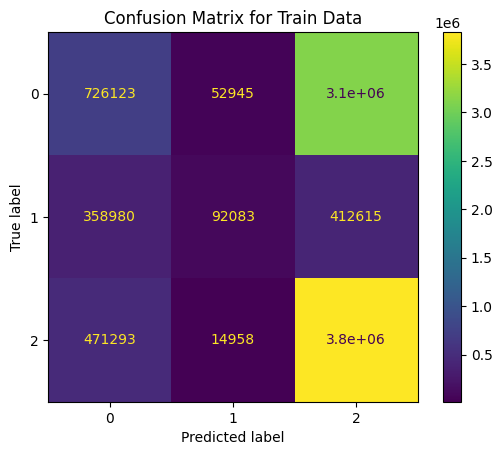

Balanced Accuracy on Training: 0.3933744945758491


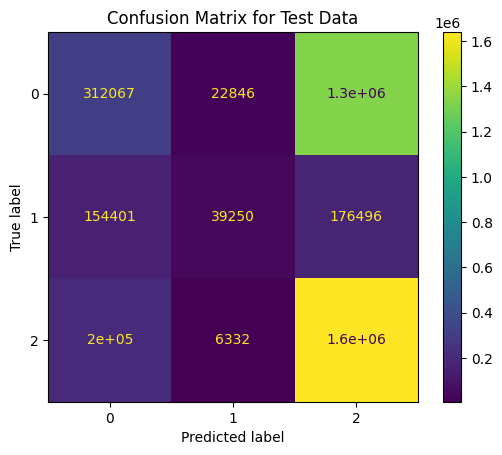

Test Set Balanced Accuracy: 0.3933060005002951


In [21]:
# https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
import matplotlib.pyplot as plt
dt_clf = DecisionTreeClassifier(min_samples_split=4, max_depth = 4, random_state=5).fit(X_train, y_train)
predictions_training = dt_clf.predict(X_train)
cm = confusion_matrix(y_train, predictions_training)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for Train Data')
plt.show()
print('Balanced Accuracy on Training:', balanced_accuracy_score(y_train, predictions_training))
predictions = dt_clf.predict(X_test)
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for Test Data')
plt.show()
print('Test Set Balanced Accuracy:', balanced_accuracy_score(y_test, predictions))

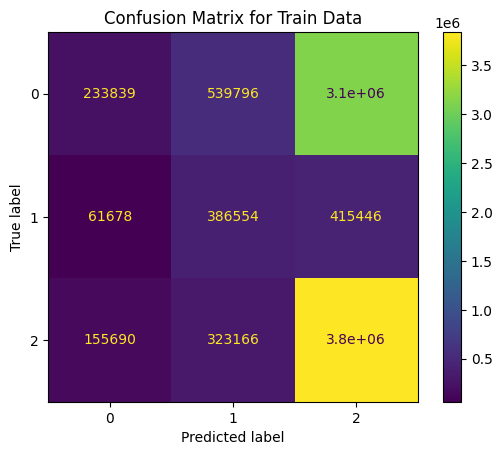

Balanced Accuracy on Training: 0.4655094099995393


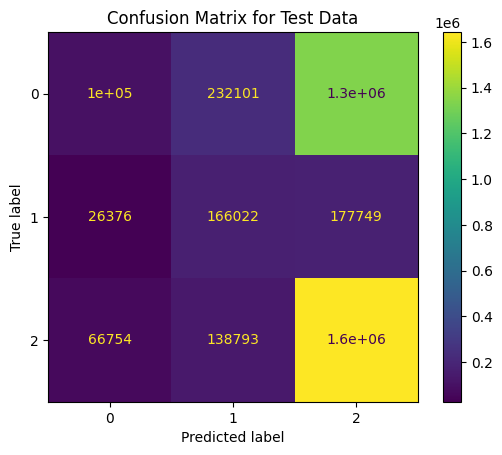

Test Set Balanced Accuracy: 0.4658389338544025


In [43]:
# https://scikit-learn.org/stable/modules/svm.html
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
from sklearn import svm
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
import matplotlib.pyplot as plt

svm_clf = svm.LinearSVC(class_weight='balanced').fit(X_train, y_train)
predictions_training = svm_clf.predict(X_train)
cm = confusion_matrix(y_train, predictions_training)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for Train Data')
plt.show()
print('Balanced Accuracy on Training:', balanced_accuracy_score(y_train, predictions_training))
predictions = svm_clf.predict(X_test)
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for Test Data')
plt.show()
print('Test Set Balanced Accuracy:', balanced_accuracy_score(y_test, predictions))

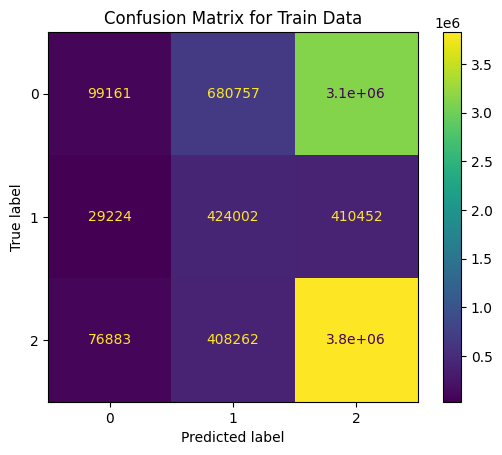

Balanced Accuracy on Training: 0.467962387721874


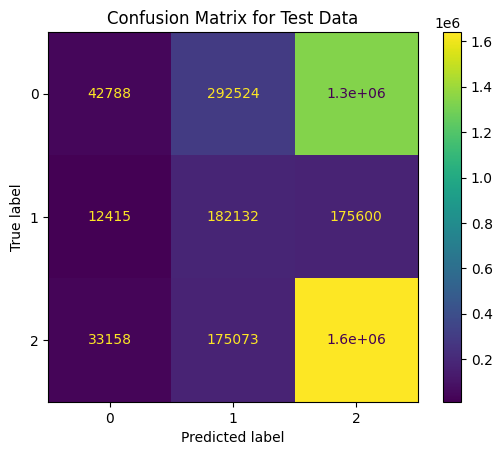

Test Set Balanced Accuracy: 0.4683398357376049


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
import matplotlib.pyplot as plt

lr = LogisticRegression(class_weight='balanced', max_iter=10000, random_state=5).fit(X_train, y_train)
predictions_training = lr.predict(X_train)
cm = confusion_matrix(y_train, predictions_training)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for Train Data')
plt.show()
print('Balanced Accuracy on Training:', balanced_accuracy_score(y_train, predictions_training))
predictions = lr.predict(X_test)
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for Test Data')
plt.show()
print('Test Set Balanced Accuracy:', balanced_accuracy_score(y_test, predictions))

In [22]:
# from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# param_grid = {
#     'C': [0.1, 1, 10],
# }

# grid_search = GridSearchCV(
#     estimator=lr,
#     param_grid=param_grid,
#     cv=3,
#     scoring='balanced_accuracy',
#     verbose=1,
#     n_jobs=-1
# )

# grid_search.fit(X_train, y_train)

# print(f"Best parameters found: {grid_search.best_params_}")
# print(f"Best balanced accuracy (cross-validation): {grid_search.best_score_:.4f}")

# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_test)
# test_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
# print(f"Test set balanced accuracy: {test_balanced_accuracy:.4f}")

In [23]:
coef_df = pd.DataFrame(
    lr.coef_,
    columns=column_names,
    index=lr.classes_
).T

# Positive values mean that feature increases the probability of that era
# Negative values mean it decreases the probability
print("Coefficients by Feature and Administration:")
display(coef_df)

for admin in lr.classes_:
    print(f"\n--- Top 5 Features predicting the {admin} Era ---")
    print(coef_df[admin].sort_values(ascending=False).head(5))

Coefficients by Feature and Administration:


,Biden,Trump_One,Trump_Two
product_Consumer Loan,-1.407047,2.292479,-0.885432
product_Credit Card or Prepaid Card,-0.142149,0.270276,-0.128127
product_Credit Reporting,-0.152471,-0.537405,0.689875
product_Debt collection,-0.416021,0.291784,0.124237
product_Debt or credit management,0.363772,-1.777545,1.413772
"product_Money Transfer, Virtual Currency, or Money Service",0.071065,-0.248121,0.177056
product_Mortgage,-0.165426,0.851296,-0.685870
product_Payday Loan,-0.220854,0.332045,-0.111191
product_Student loan,-0.397918,0.701603,-0.303686
product_Vehicle loan or lease,-0.162343,0.261687,-0.099344



--- Top 5 Features predicting the Biden Era ---
submitted_via_Phone                                             0.579480
company_response_to_consumer_Closed with non-monetary relief    0.574031
submitted_via_Web                                               0.368890
product_Debt or credit management                               0.363772
submitted_via_Referral                                          0.193746
Name: Biden, dtype: float64

--- Top 5 Features predicting the Trump_One Era ---
product_Consumer Loan      2.292479
product_Mortgage           0.851296
product_Student loan       0.701603
product_Payday Loan        0.332045
product_Debt collection    0.291784
Name: Trump_One, dtype: float64

--- Top 5 Features predicting the Trump_Two Era ---
submitted_via_Web                                 1.522368
product_Debt or credit management                 1.413772
company_response_to_consumer_Untimely response    1.084984
product_Credit Reporting                          0.689875
time

In [24]:
intercept_df = pd.DataFrame(lr.intercept_, index=lr.classes_, columns=['Intercept'])
print(intercept_df)

           Intercept
Biden      -0.268979
Trump_One   2.766402
Trump_Two  -2.497423


In [25]:
import numpy as np
import pandas as pd

odds_ratios = np.exp(lr.coef_)

or_df = pd.DataFrame(
    odds_ratios,
    columns=column_names,
    index=lr.classes_
).T

# "Percent Change" version for easier reading
pct_df = (or_df - 1) * 100

print("--- Odds Ratios (Likelihood Multiplier) ---")
display(or_df.head(10))

for admin in lr.classes_:
    print(f"\nTop indicators for {admin}:")
    # Sort by the highest percentage increase
    top_indicators = pct_df[admin].sort_values(ascending=False).head(5)
    for feature, val in top_indicators.items():
        print(f" > {feature}: {val:.1f}% more likely")

--- Odds Ratios (Likelihood Multiplier) ---


,Biden,Trump_One,Trump_Two
product_Consumer Loan,0.244865,9.899444,0.412536
product_Credit Card or Prepaid Card,0.867492,1.310326,0.879742
product_Credit Reporting,0.858584,0.584263,1.993467
product_Debt collection,0.659667,1.338814,1.132284
product_Debt or credit management,1.438747,0.169053,4.111436
"product_Money Transfer, Virtual Currency, or Money Service",1.073651,0.780265,1.193698
product_Mortgage,0.847532,2.342681,0.503652
product_Payday Loan,0.801834,1.393815,0.894768
product_Student loan,0.671717,2.016984,0.738093
product_Vehicle loan or lease,0.850150,1.299120,0.905431



Top indicators for Biden:
 > submitted_via_Phone: 78.5% more likely
 > company_response_to_consumer_Closed with non-monetary relief: 77.5% more likely
 > submitted_via_Web: 44.6% more likely
 > product_Debt or credit management: 43.9% more likely
 > submitted_via_Referral: 21.4% more likely

Top indicators for Trump_One:
 > product_Consumer Loan: 889.9% more likely
 > product_Mortgage: 134.3% more likely
 > product_Student loan: 101.7% more likely
 > product_Payday Loan: 39.4% more likely
 > product_Debt collection: 33.9% more likely

Top indicators for Trump_Two:
 > submitted_via_Web: 358.3% more likely
 > product_Debt or credit management: 311.1% more likely
 > company_response_to_consumer_Untimely response: 195.9% more likely
 > product_Credit Reporting: 99.3% more likely
 > timely_response_Yes: 52.9% more likely
